# Software Development Oriented to Machine Learning

This notebook explores a dataset of potentially hazardous asteroids and develops a baseline regression model to predict impact probability.

The analysis includes data exploration, preprocessing, visualization, model training, and evaluation.
## Contents

1. [Importing Libraries](#1-importing-libraries)
2. [Loading the Dataset](#2-loading-the-dataset)
   - [2.1 Dataset Overview](#21-dataset-overview)
   - [2.2 Missing Values](#22-missing-values)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
   - [3.1 Correlation Analysis](#31-correlation-analysis)
   - [3.2 Impact Probability Distribution](#32-impact-probability-distribution)
   - [3.3 Risk and Asteroid Characteristics](#33-risk-and-asteroid-characteristics)
   - [3.4 Potential Impact Timeline](#34-potential-impact-timeline)
4. [Data Preprocessing](#4-data-preprocessing)
   - [4.1 Handling Missing Values](#41-handling-missing-values)
   - [4.2 Target Transformation](#42-target-transformation)
   - [4.3 Feature Selection](#43-feature-selection)
   - [4.4 Train-Test Split](#44-train-test-split)
   - [4.5 Feature Scaling](#45-feature-scaling)
5. [Baseline Model](#5-baseline-model)
   - [5.1 Model Architecture](#51-model-architecture)
   - [5.2 Model Training](#52-model-training)
   - [5.3 Model Evaluation](#53-model-evaluation)
6. [Results](#6-results)
   - [6.1 Training History](#61-training-history)
   - [6.2 Model Performance](#62-model-performance)
7. [Conclusions](#7-conclusions)



## 1. Importing Libraries

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers

## 2. Loading the Dataset

The dataset contains information about near-Earth objects and their potential impact risk. It includes orbital characteristics, impact probabilities, Palermo and Torino scales, and information about potential encounter years.

### 2.1 Dataset Overview

In [ ]:
df = pd.read_parquet(
    "hf://datasets/juliensimon/sentry-impact-risk/data/sentry_impact_risk.parquet"
)
df.head()

In [12]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2202 entries, 0 to 2201
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   torino_scale         2200 non-null   float64       
 1   n_potential_impacts  2202 non-null   int64         
 2   last_observation     2201 non-null   datetime64[us]
 3   designation          2202 non-null   object        
 4   impact_probability   2202 non-null   float64       
 5   palermo_scale_cum    2202 non-null   float64       
 6   last_observation_jd  2202 non-null   float64       
 7   full_name            2202 non-null   object        
 8   v_infinity_kms       2198 non-null   float64       
 9   absolute_magnitude   2202 non-null   float64       
 10  diameter_km          2202 non-null   float64       
 11  palermo_scale_max    2202 non-null   float64       
 12  year_range_min       2202 non-null   Int64         
 13  year_range_max       2202 non-nul

,torino_scale,n_potential_impacts,last_observation,impact_probability,palermo_scale_cum,last_observation_jd,v_infinity_kms,absolute_magnitude,diameter_km,palermo_scale_max,year_range_min,year_range_max
count,2200.0,2202.000000,2201,2.202000e+03,2202.000000,2.202000e+03,2198.000000,2202.000000,2202.000000,2202.000000,2202.0,2202.0
mean,0.0,20.957312,2019-05-13 03:48:59.209450,1.299936e-04,-6.896608,2.458617e+06,10.979569,27.278433,0.019328,-7.111340,2079.668483,2107.404632
min,0.0,1.000000,1979-12-15 00:00:00,1.008000e-10,-12.140000,2.444222e+06,0.410758,17.630000,0.000990,-12.140000,2026.0,2026.0
25%,0.0,2.000000,2016-05-17 00:00:00,1.984426e-07,-7.870000,2.457526e+06,7.261860,26.180000,0.006800,-8.060000,2060.0,2100.0
50%,0.0,5.000000,2021-02-10 00:00:00,2.307960e-06,-6.810000,2.459256e+06,9.919835,27.365000,0.011000,-7.090000,2080.0,2118.0
75%,0.0,18.000000,2023-12-13 00:00:00,2.083606e-05,-5.880000,2.460291e+06,14.060505,28.477500,0.020000,-6.120000,2100.0,2121.75
max,0.0,972.000000,2026-09-13 00:00:00,1.026373e-01,-0.930000,2.461296e+06,40.250000,32.670000,1.300000,-0.930000,2880.0,2880.0
std,0.0,51.367550,NaN,2.292428e-03,1.506577,2.262850e+03,5.598857,1.865249,0.047756,1.473017,30.418824,27.401407


### 2.2 Missing Values

Before preprocessing the data, we inspect the dataset for missing values.

In [13]:
missing_values = df.isna().sum()

missing_values

torino_scale           2
n_potential_impacts    0
last_observation       1
designation            0
impact_probability     0
palermo_scale_cum      0
last_observation_jd    0
full_name              0
v_infinity_kms         4
absolute_magnitude     0
diameter_km            0
palermo_scale_max      0
year_range_min         0
year_range_max         0
dtype: int64

In [14]:
missing_percentage = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_percentage

v_infinity_kms         0.181653
torino_scale           0.090827
last_observation       0.045413
n_potential_impacts    0.000000
impact_probability     0.000000
designation            0.000000
palermo_scale_cum      0.000000
last_observation_jd    0.000000
full_name              0.000000
absolute_magnitude     0.000000
diameter_km            0.000000
palermo_scale_max      0.000000
year_range_min         0.000000
year_range_max         0.000000
dtype: float64

## 3. Exploratory Data Analysis

This section explores the numerical relationships and distributions in the dataset before training the regression model.

### 3.1 Correlation Analysis

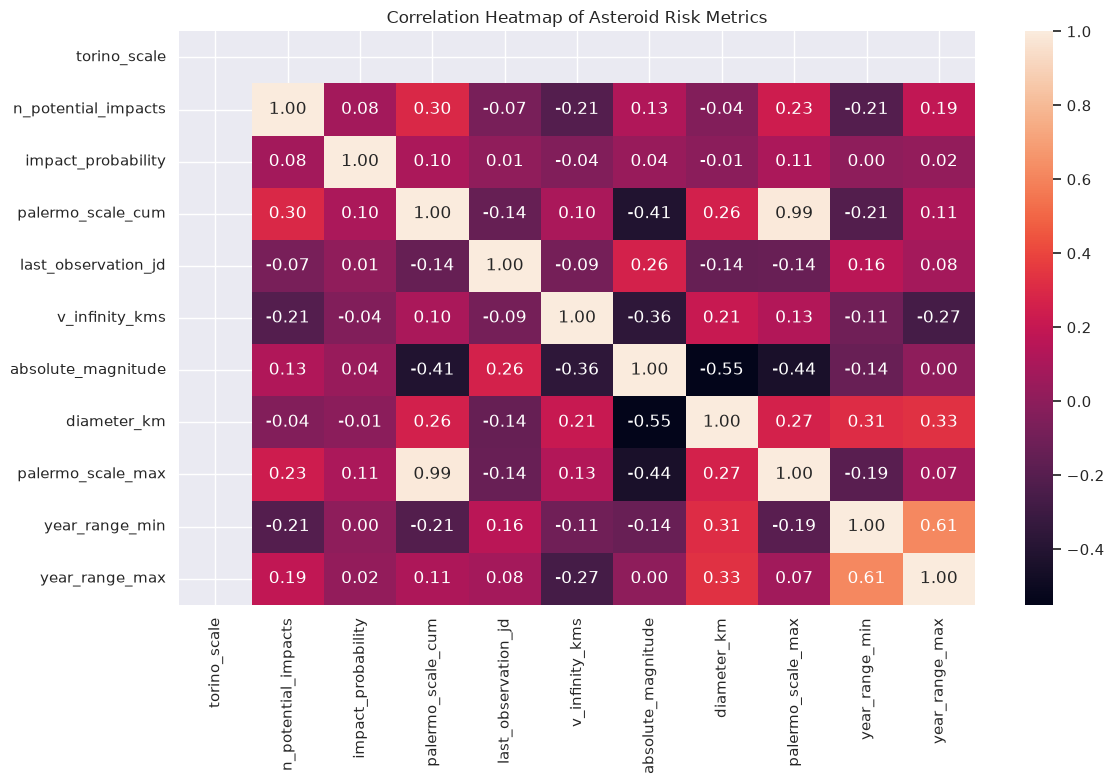

In [15]:
numeric_cols = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    fmt=".2f",
)

plt.title("Correlation Heatmap of Asteroid Risk Metrics")
plt.tight_layout()
plt.show()

### 3.2 Impact Probability Distribution

Impact probabilities are very small values. A logarithmic transformation makes their distribution easier to visualize.

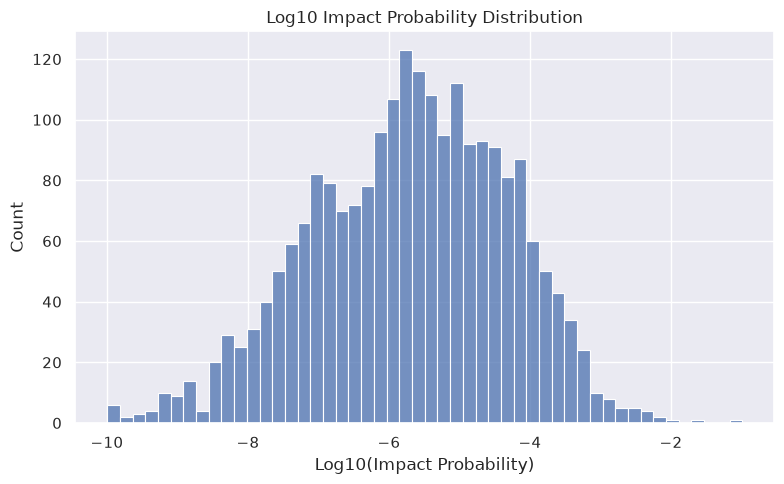

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    np.log10(df["impact_probability"]),
    bins=50,
)

plt.title("Log10 Impact Probability Distribution")
plt.xlabel("Log10(Impact Probability)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.3 Risk and Asteroid Characteristics

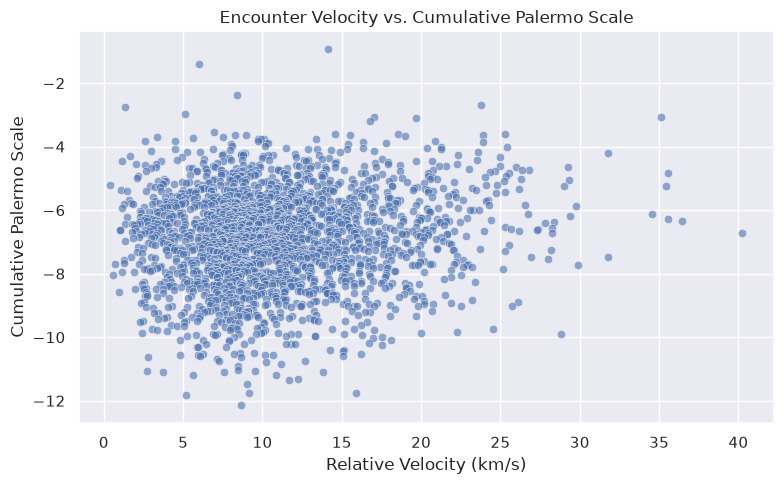

In [17]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="v_infinity_kms",
    y="palermo_scale_cum",
    alpha=0.6,
)

plt.title("Encounter Velocity vs. Cumulative Palermo Scale")
plt.xlabel("Relative Velocity (km/s)")
plt.ylabel("Cumulative Palermo Scale")
plt.tight_layout()
plt.show()

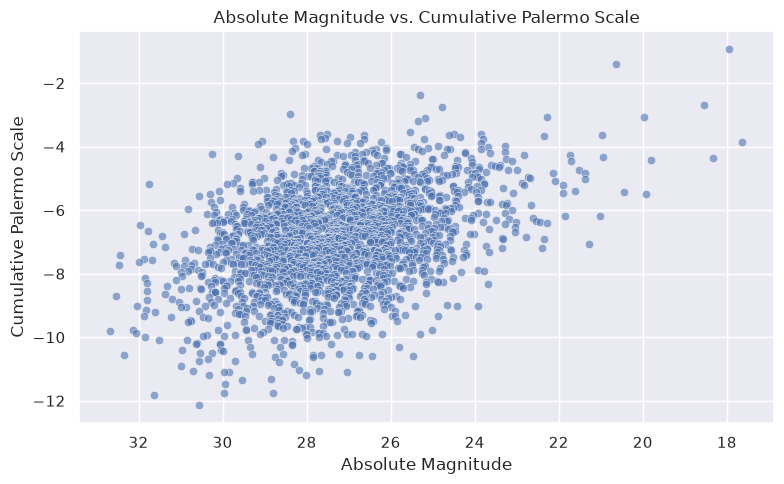

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="absolute_magnitude",
    y="palermo_scale_cum",
    alpha=0.6,
)

plt.gca().invert_xaxis()

plt.title("Absolute Magnitude vs. Cumulative Palermo Scale")
plt.xlabel("Absolute Magnitude")
plt.ylabel("Cumulative Palermo Scale")
plt.tight_layout()
plt.show()

### 3.4 Potential Impact Timeline

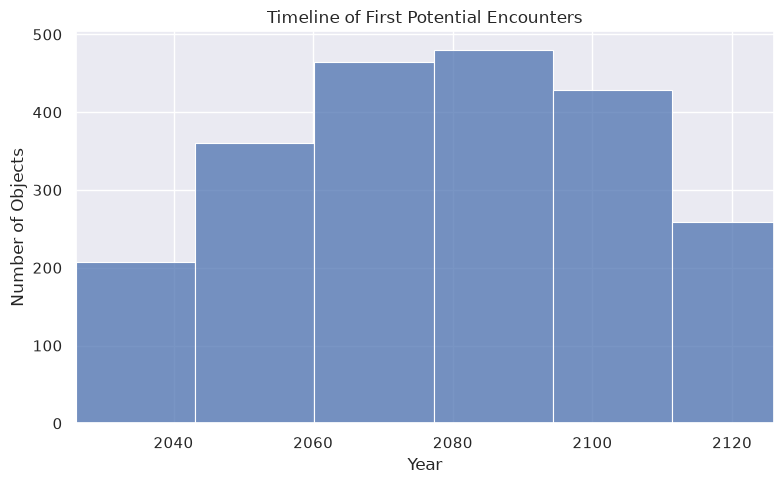

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["year_range_min"].dropna(),
    bins=50,
)

plt.title("Timeline of First Potential Encounters")
plt.xlabel("Year")
plt.ylabel("Number of Objects")
plt.xlim(2026, 2126)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Before training the regression model, the dataset is cleaned and transformed. Missing values are removed, the target variable is transformed logarithmically, relevant numerical features are selected, and the data is divided into training and test sets.

### 4.1 Handling Missing Values

In [20]:
df_reg = df.dropna().copy()

print(f"Original dataset size: {len(df)}")
print(f"Dataset size after removing missing values: {len(df_reg)}")

Original dataset size: 2202
Dataset size after removing missing values: 2196


### 4.2 Target Transformation

The impact probability values are very small. Therefore, the target variable is transformed using the base-10 logarithm.

In [21]:
df_reg["log_impact_probability"] = np.log10(
    df_reg["impact_probability"]
)

### 4.3 Feature Selection

In [22]:
features = df_reg.select_dtypes(include="number").columns.tolist()

features.remove("impact_probability")
features.remove("log_impact_probability")

X = df_reg[features]
y = df_reg["log_impact_probability"]

print("Selected features:")
print(features)

print(f"\nNumber of features: {X.shape[1]}")

Selected features:
['torino_scale', 'n_potential_impacts', 'palermo_scale_cum', 'last_observation_jd', 'v_infinity_kms', 'absolute_magnitude', 'diameter_km', 'palermo_scale_max', 'year_range_min', 'year_range_max']

Number of features: 10


### 4.4 Train-Test Split

The dataset is divided into training and test sets. The test set contains 20% of the observations and is kept separate for the final model evaluation.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 1756
Test samples: 440


### 4.5 Feature Scaling

The numerical features are standardized using `StandardScaler`. The scaler is fitted only on the training data to avoid data leakage.

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 5. Baseline Model

A baseline neural network is trained to predict the logarithm of the impact probability. The model provides a first reference point for evaluating the performance of the regression approach.

### 5.1 Model Architecture

The model is a simple feed-forward neural network with two hidden layers. ReLU activation is used in the hidden layers, while the output layer contains a single neuron because this is a regression problem.

In [25]:
model = tf.keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Model Training

The model is trained using the Adam optimizer and Mean Squared Error (MSE) as the loss function. Mean Absolute Error (MAE) is also monitored during training.

A validation split of 10% of the training data is used to monitor the model's performance on unseen data during training.

In [26]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=2,
)

Epoch 1/10
25/25 - 2s - 69ms/step - loss: 25.5693 - mae: 4.8346 - val_loss: 16.5872 - val_mae: 3.8357
Epoch 2/10
25/25 - 0s - 10ms/step - loss: 8.1928 - mae: 2.4963 - val_loss: 7.1993 - val_mae: 1.7049
Epoch 3/10
25/25 - 0s - 10ms/step - loss: 3.4713 - mae: 1.3902 - val_loss: 4.6794 - val_mae: 1.3598
Epoch 4/10
25/25 - 0s - 13ms/step - loss: 2.2234 - mae: 1.1480 - val_loss: 3.3173 - val_mae: 1.1532
Epoch 5/10
25/25 - 0s - 12ms/step - loss: 1.6387 - mae: 0.9882 - val_loss: 2.2552 - val_mae: 0.9959
Epoch 6/10
25/25 - 0s - 8ms/step - loss: 1.2222 - mae: 0.8627 - val_loss: 1.6283 - val_mae: 0.8901
Epoch 7/10
25/25 - 0s - 8ms/step - loss: 0.9497 - mae: 0.7669 - val_loss: 1.2407 - val_mae: 0.7997
Epoch 8/10
25/25 - 0s - 8ms/step - loss: 0.7692 - mae: 0.6918 - val_loss: 0.9369 - val_mae: 0.7145
Epoch 9/10
25/25 - 0s - 8ms/step - loss: 0.6373 - mae: 0.6318 - val_loss: 0.7721 - val_mae: 0.6568
Epoch 10/10
25/25 - 0s - 8ms/step - loss: 0.5470 - mae: 0.5837 - val_loss: 0.6179 - val_mae: 0.5911


### 5.3 Model Evaluation

After training, the model is evaluated on the test set. The test data has not been used during training or validation, providing an independent estimate of the model's performance.

In [27]:
test_loss, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0,
)

print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test MSE: 0.5674
Test MAE: 0.5681


## 6. Results

This section visualizes the training process and summarizes the performance of the baseline regression model.

### 6.1 Training History

The training and validation curves show how the model's error changes throughout the training process. Comparing both curves helps identify whether the model is learning effectively and whether there are signs of overfitting.

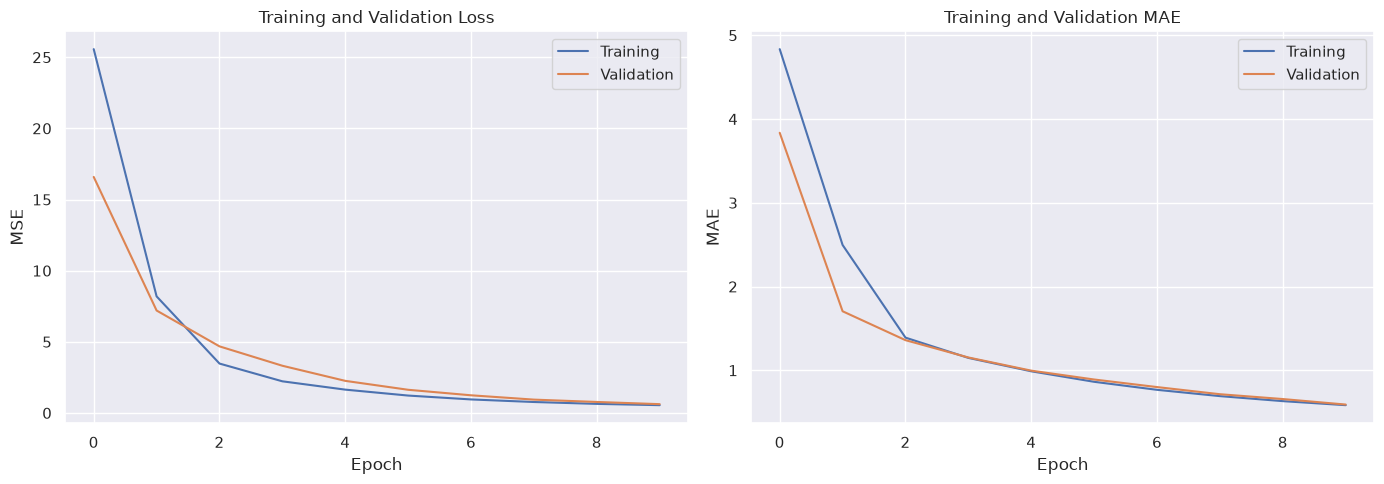

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history.history["loss"],
    label="Training",
)
axes[0].plot(
    history.history["val_loss"],
    label="Validation",
)

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()


axes[1].plot(
    history.history["mae"],
    label="Training",
)
axes[1].plot(
    history.history["val_mae"],
    label="Validation",
)

axes[1].set_title("Training and Validation MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 Model Performance

The baseline model achieves the following performance on the test set:

In [29]:
results = pd.DataFrame(
    {
        "Metric": ["MSE", "MAE"],
        "Test value": [test_loss, test_mae],
    }
)

results

,Metric,Test value
0,MSE,0.567412
1,MAE,0.568139


## 7. Conclusions

The dataset contains several numerical variables related to asteroid characteristics and potential impact risk. Exploratory analysis was used to understand the relationships between these variables before training the model.

A baseline neural network was trained to predict the logarithm of the impact probability. The model provides a first reference for the regression task, with the training history showing how the error changes during learning.

This baseline can be used as a starting point for future experiments with different model architectures, hyperparameters, preprocessing techniques, or alternative regression algorithms.